# Amazon Review Sentiment Analysis

## Objective
This notebook builds a lightweight sentiment classifier for Amazon Electronics reviews using TF-IDF features and classical machine learning models.

The notebook focuses not only on overall performance, but also on:
- class imbalance handling
- threshold optimization
- model comparison
- ablation study
- slice-based evaluation
- error analysis

This structure is designed to make the workflow easy to run from top to bottom and easy to reuse for the final README and results folder.

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    auc
)
from sklearn.calibration import calibration_curve

## 1. Load Data
We load the processed Amazon Electronics review dataset and define the input text and sentiment labels.

In [26]:
df = pd.read_csv("../data/processed/amazon_sentiment_processed.csv")

In [27]:
x = df["reviewText"]
y = df["sentiment"]
print(y.value_counts())

sentiment
positive    84287
negative     8807
Name: count, dtype: int64


## 2. Exploratory Data Analysis
We visualize class distribution and review length distribution to understand the dataset before training.

In [28]:
os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/error_analysis", exist_ok=True)

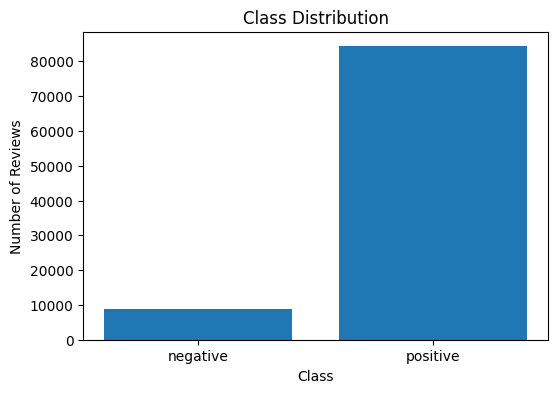

In [29]:
label_counts = df["sentiment"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.xlabel("Class")
plt.ylabel("Number of Reviews")
plt.title("Class Distribution")
plt.savefig("../results/figures/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

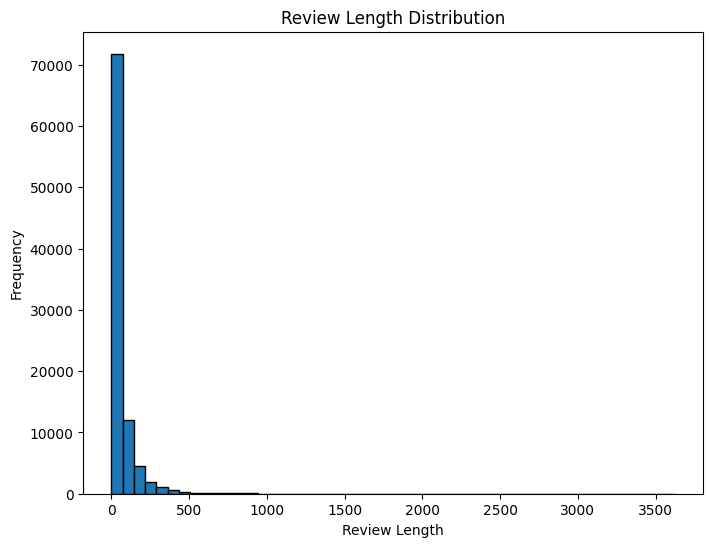

In [30]:
df["review_length"] = df["reviewText"].astype(str).apply(lambda text: len(text.split()))
plt.figure(figsize=(8, 6))
plt.hist(df["review_length"], bins=50, edgecolor="black")
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Review Length Distribution")
plt.savefig("../results/figures/review_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Train-Test Split
We split the dataset into training and test sets for evaluation.

In [31]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(x_train))
print("Test size:", len(x_test))

Train size: 74475
Test size: 18619


## 4. TF-IDF Feature Extraction
We convert review text into numerical features using TF-IDF.

In [32]:
vectorizer = TfidfVectorizer(max_features=5000)

x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

print("x_train_tfidf shape:", x_train_tfidf.shape)
print("x_test_tfidf shape:", x_test_tfidf.shape)

x_train_tfidf shape: (74475, 5000)
x_test_tfidf shape: (18619, 5000)


## 5. Logistic Regression Baseline (Unweighted)
We first train a standard Logistic Regression model without class weighting.

In [33]:
model_lr_unweighted = LogisticRegression(max_iter=1000, random_state=42)
model_lr_unweighted.fit(x_train_tfidf, y_train)

y_pred_lr_unweighted = model_lr_unweighted.predict(x_test_tfidf)
print(classification_report(y_test, y_pred_lr_unweighted))

              precision    recall  f1-score   support

    negative       0.85      0.50      0.63      1745
    positive       0.95      0.99      0.97     16874

    accuracy                           0.94     18619
   macro avg       0.90      0.75      0.80     18619
weighted avg       0.94      0.94      0.94     18619



In [34]:
lr_unweighted_accuracy = accuracy_score(y_test, y_pred_lr_unweighted)
lr_unweighted_precision = precision_score(y_test, y_pred_lr_unweighted, pos_label="positive", zero_division=0)
lr_unweighted_recall = recall_score(y_test, y_pred_lr_unweighted, pos_label="positive", zero_division=0)
lr_unweighted_f1 = f1_score(y_test, y_pred_lr_unweighted, pos_label="positive", zero_division=0)

print("Logistic Regression (unweighted)")
print("Accuracy :", round(lr_unweighted_accuracy, 4))
print("Precision:", round(lr_unweighted_precision, 4))
print("Recall   :", round(lr_unweighted_recall, 4))
print("F1-score :", round(lr_unweighted_f1, 4))

Logistic Regression (unweighted)
Accuracy : 0.9449
Precision: 0.9508
Recall   : 0.9905
F1-score : 0.9702


## 6. Logistic Regression with Class Weighting
To address class imbalance, we train a second Logistic Regression model using `class_weight="balanced"`.

In [35]:
model_lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
model_lr_balanced.fit(x_train_tfidf, y_train)

y_pred_lr_balanced = model_lr_balanced.predict(x_test_tfidf)
print(classification_report(y_test, y_pred_lr_balanced))


              precision    recall  f1-score   support

    negative       0.49      0.88      0.63      1745
    positive       0.99      0.91      0.94     16874

    accuracy                           0.90     18619
   macro avg       0.74      0.89      0.79     18619
weighted avg       0.94      0.90      0.92     18619



In [36]:
lr_balanced_accuracy = accuracy_score(y_test, y_pred_lr_balanced)
lr_balanced_precision = precision_score(y_test, y_pred_lr_balanced, pos_label="positive", zero_division=0)
lr_balanced_recall = recall_score(y_test, y_pred_lr_balanced, pos_label="positive", zero_division=0)
lr_balanced_f1 = f1_score(y_test, y_pred_lr_balanced, pos_label="positive", zero_division=0)

print("Logistic Regression (balanced, threshold=0.5)")
print("Accuracy :", round(lr_balanced_accuracy, 4))
print("Precision:", round(lr_balanced_precision, 4))
print("Recall   :", round(lr_balanced_recall, 4))
print("F1-score :", round(lr_balanced_f1, 4))

Logistic Regression (balanced, threshold=0.5)
Accuracy : 0.9038
Precision: 0.986
Recall   : 0.9067
F1-score : 0.9447


In [9]:
y_pred = model_balanced.predict(x_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.49      0.88      0.63      1745
    positive       0.99      0.91      0.94     16874

    accuracy                           0.90     18619
   macro avg       0.74      0.89      0.79     18619
weighted avg       0.94      0.90      0.92     18619



## 7. Threshold Optimization
Instead of using the default decision threshold of 0.5, we search for a threshold that maximizes F1-score.


In [37]:
y_prob_lr_balanced = model_lr_balanced.predict_proba(x_test_tfidf)[:, 1]
y_test_binary = y_test.map({"negative": 0, "positive": 1})

In [38]:
thresholds = np.arange(0.05, 0.96, 0.01)
threshold_results = []

for t in thresholds:
    y_pred_tuned = np.where(y_prob_lr_balanced >= t, "positive", "negative")
    threshold_results.append({
        "threshold": round(float(t), 2),
        "accuracy": accuracy_score(y_test, y_pred_tuned),
        "precision": precision_score(y_test, y_pred_tuned, pos_label="positive", zero_division=0),
        "recall": recall_score(y_test, y_pred_tuned, pos_label="positive", zero_division=0),
        "f1": f1_score(y_test, y_pred_tuned, pos_label="positive", zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.head()


,threshold,accuracy,precision,recall,f1
0,0.05,0.936033,0.937218,0.996148,0.965785
1,0.06,0.937698,0.939823,0.994963,0.966607
2,0.07,0.939470,0.942456,0.993896,0.967493
3,0.08,0.941028,0.944645,0.993126,0.968279
4,0.09,0.942371,0.947088,0.991822,0.968939


In [39]:
best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_threshold = best_row["threshold"]

print("Best threshold:", best_threshold)
best_row

Best threshold: 0.16


threshold    0.160000
accuracy     0.946238
precision    0.959049
recall       0.982636
f1           0.970699
Name: 11, dtype: float64

In [14]:
import numpy as np
import pandas as pd

thresholds = np.arange(0.05, 0.96, 0.01)
threshold_results = []

for t in thresholds:
    y_pred_tuned = np.where(y_prob_lr_balanced >= t, "positive", "negative")
    
    precision = precision_score(y_test, y_pred_tuned, pos_label="positive", zero_division=0)
    recall = recall_score(y_test, y_pred_tuned, pos_label="positive", zero_division=0)
    f1 = f1_score(y_test, y_pred_tuned, pos_label="positive", zero_division=0)
    accuracy = accuracy_score(y_test, y_pred_tuned)
    
    threshold_results.append({
        "threshold": round(t, 2),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.head()

,threshold,accuracy,precision,recall,f1
0,0.05,0.936033,0.937218,0.996148,0.965785
1,0.06,0.937698,0.939823,0.994963,0.966607
2,0.07,0.939470,0.942456,0.993896,0.967493
3,0.08,0.941028,0.944645,0.993126,0.968279
4,0.09,0.942371,0.947088,0.991822,0.968939


In [15]:
best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_threshold = best_row["threshold"]

print("Best threshold:", best_threshold)
print(best_row)

Best threshold: 0.16
threshold    0.160000
accuracy     0.946238
precision    0.959049
recall       0.982636
f1           0.970699
Name: 11, dtype: float64


In [40]:
y_pred_lr_balanced_tuned = np.where(
    y_prob_lr_balanced >= best_threshold,
    "positive",
    "negative"
)

lr_balanced_tuned_accuracy = accuracy_score(y_test, y_pred_lr_balanced_tuned)
lr_balanced_tuned_precision = precision_score(y_test, y_pred_lr_balanced_tuned, pos_label="positive", zero_division=0)
lr_balanced_tuned_recall = recall_score(y_test, y_pred_lr_balanced_tuned, pos_label="positive", zero_division=0)
lr_balanced_tuned_f1 = f1_score(y_test, y_pred_lr_balanced_tuned, pos_label="positive", zero_division=0)

print("Logistic Regression (balanced, tuned threshold)")
print("Threshold:", best_threshold)
print("Accuracy :", round(lr_balanced_tuned_accuracy, 4))
print("Precision:", round(lr_balanced_tuned_precision, 4))
print("Recall   :", round(lr_balanced_tuned_recall, 4))
print("F1-score :", round(lr_balanced_tuned_f1, 4))

Logistic Regression (balanced, tuned threshold)
Threshold: 0.16
Accuracy : 0.9462
Precision: 0.959
Recall   : 0.9826
F1-score : 0.9707


## 8. Threshold Diagnostics
We visualize the precision-recall trade-off, ROC curve, threshold-vs-F1 behavior, and confusion matrix.

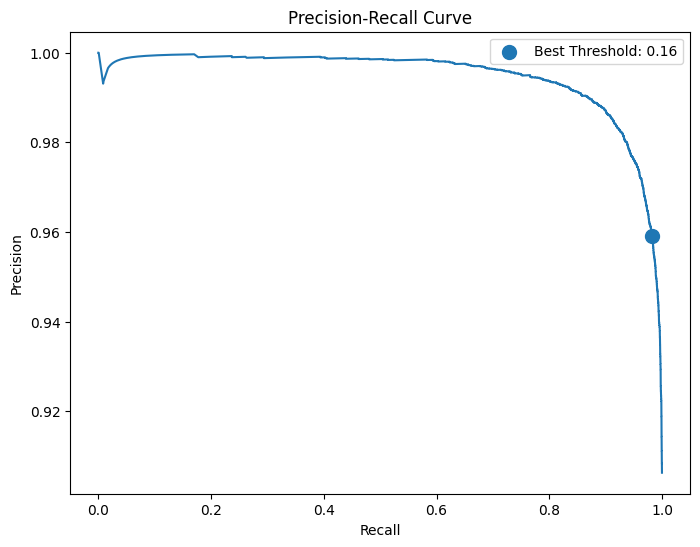

In [41]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test_binary, y_prob_lr_balanced)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve)
idx = np.argmin(np.abs(pr_thresholds - best_threshold))
plt.scatter(
    recall_curve[idx + 1],
    precision_curve[idx + 1],
    s=100,
    label=f"Best Threshold: {best_threshold:.2f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.savefig("../results/figures/pr_curve.png", dpi=300, bbox_inches="tight")
plt.show()

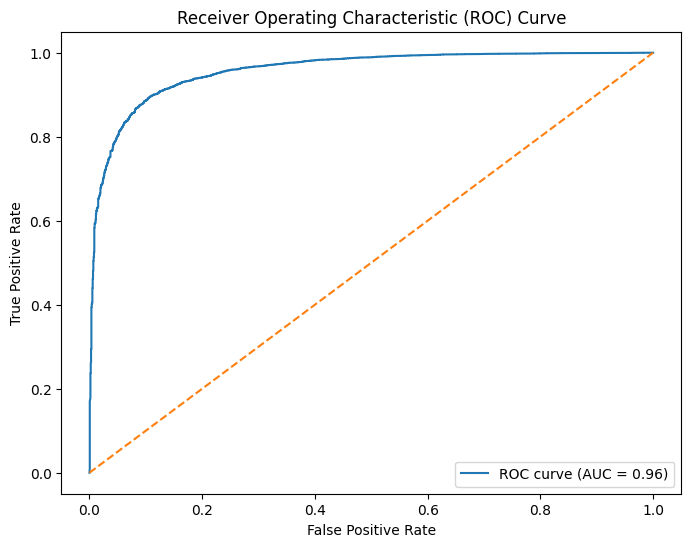

In [42]:
fpr, tpr, roc_thresholds = roc_curve(y_test_binary, y_prob_lr_balanced)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.savefig("../results/figures/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

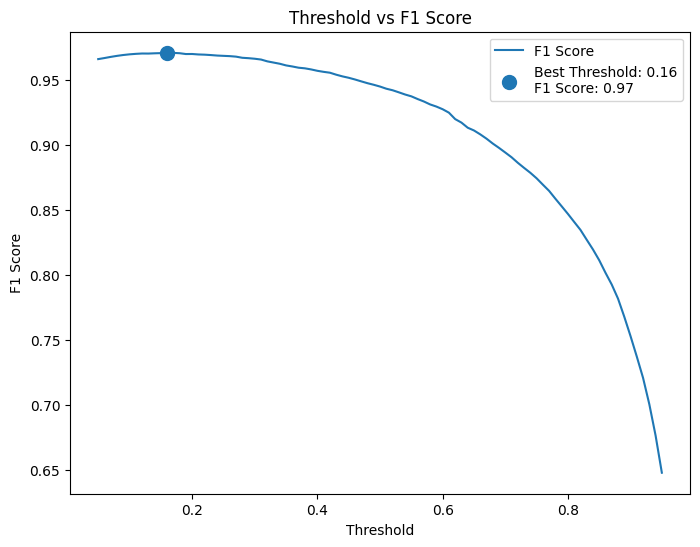

In [43]:
best_idx = threshold_df["f1"].idxmax()
best_f1 = threshold_df.loc[best_idx, "f1"]

plt.figure(figsize=(8, 6))
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1 Score")
plt.scatter(best_threshold, best_f1, s=100, label=f"Best Threshold: {best_threshold:.2f}\nF1 Score: {best_f1:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1 Score")
plt.legend()
plt.savefig("../results/figures/threshold_vs_f1.png", dpi=300, bbox_inches="tight")
plt.show()

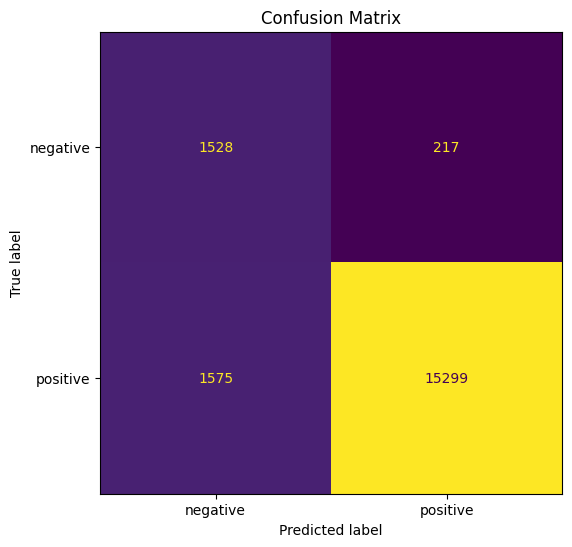

In [44]:
y_pred_default_binary = np.where(y_prob_lr_balanced >= 0.5, 1, 0)
cm = confusion_matrix(y_test_binary, y_pred_default_binary)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.savefig("../results/figures/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Multinomial Naive Bayes Baseline
We also train a Naive Bayes baseline for comparison.

In [45]:
model_nb = MultinomialNB()
model_nb.fit(x_train_tfidf, y_train)

y_pred_nb = model_nb.predict(x_test_tfidf)
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

    negative       0.92      0.11      0.20      1745
    positive       0.92      1.00      0.96     16874

    accuracy                           0.92     18619
   macro avg       0.92      0.56      0.58     18619
weighted avg       0.92      0.92      0.88     18619



In [46]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, pos_label="positive", zero_division=0)
nb_recall = recall_score(y_test, y_pred_nb, pos_label="positive", zero_division=0)
nb_f1 = f1_score(y_test, y_pred_nb, pos_label="positive", zero_division=0)

print("Multinomial Naive Bayes")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1-score :", round(nb_f1, 4))

Multinomial Naive Bayes
Accuracy : 0.9159
Precision: 0.9158
Recall   : 0.9991
F1-score : 0.9556


## 10. Model Comparison
We compare all trained models and configurations using the same evaluation metrics.

In [47]:
model_comparison = pd.DataFrame([
    {
        "model": "Multinomial Naive Bayes",
        "setting": "default",
        "accuracy": nb_accuracy,
        "precision": nb_precision,
        "recall": nb_recall,
        "f1": nb_f1
    },
    {
        "model": "Logistic Regression",
        "setting": "unweighted (threshold=0.5)",
        "accuracy": lr_unweighted_accuracy,
        "precision": lr_unweighted_precision,
        "recall": lr_unweighted_recall,
        "f1": lr_unweighted_f1
    },
    {
        "model": "Logistic Regression",
        "setting": "balanced (threshold=0.5)",
        "accuracy": lr_balanced_accuracy,
        "precision": lr_balanced_precision,
        "recall": lr_balanced_recall,
        "f1": lr_balanced_f1
    },
    {
        "model": "Logistic Regression",
        "setting": f"balanced (threshold={best_threshold})",
        "accuracy": lr_balanced_tuned_accuracy,
        "precision": lr_balanced_tuned_precision,
        "recall": lr_balanced_tuned_recall,
        "f1": lr_balanced_tuned_f1
    }
]).sort_values(by="f1", ascending=False)

model_comparison

,model,setting,accuracy,precision,recall,f1
3,Logistic Regression,balanced (threshold=0.16),0.946238,0.959049,0.982636,0.970699
1,Logistic Regression,unweighted (threshold=0.5),0.944949,0.950845,0.990459,0.970248
0,Multinomial Naive Bayes,default,0.915946,0.915847,0.999052,0.955642
2,Logistic Regression,balanced (threshold=0.5),0.903754,0.986014,0.906661,0.944674


## 11. Ablation Study
This section isolates the effect of two key choices:
- class weighting
- threshold tuning

In [48]:
ablation_results = pd.DataFrame([
    {
        "experiment": "class_weight",
        "setting": "unweighted (threshold=0.5)",
        "f1": lr_unweighted_f1
    },
    {
        "experiment": "class_weight",
        "setting": "balanced (threshold=0.5)",
        "f1": lr_balanced_f1
    },
    {
        "experiment": "threshold",
        "setting": "balanced (threshold=0.5)",
        "f1": lr_balanced_f1
    },
    {
        "experiment": "threshold",
        "setting": f"balanced (threshold={best_threshold})",
        "f1": lr_balanced_tuned_f1
    }
])

ablation_results

,experiment,setting,f1
0,class_weight,unweighted (threshold=0.5),0.970248
1,class_weight,balanced (threshold=0.5),0.944674
2,threshold,balanced (threshold=0.5),0.944674
3,threshold,balanced (threshold=0.16),0.970699


## 12. Model Interpretation
We inspect the most influential TF-IDF features from the unweighted Logistic Regression model.

In [49]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model_lr_unweighted.coef_[0]

coef_df = pd.DataFrame({
    "word": feature_names,
    "weight": coefficients
})

top_positive = coef_df.sort_values(by="weight", ascending=False).head(20)
top_negative = coef_df.sort_values(by="weight", ascending=True).head(20)

top_positive.head(), top_negative.head()

(           word     weight
 1989      great  10.381047
 2593       love   6.541068
 4932      works   6.492708
 3148    perfect   6.300353
 1601  excellent   6.164925,
            word    weight
 2944        not -7.924729
 3266       poor -6.609025
 4697    useless -6.348785
 3668     return -6.027829
 3670  returning -5.693170)

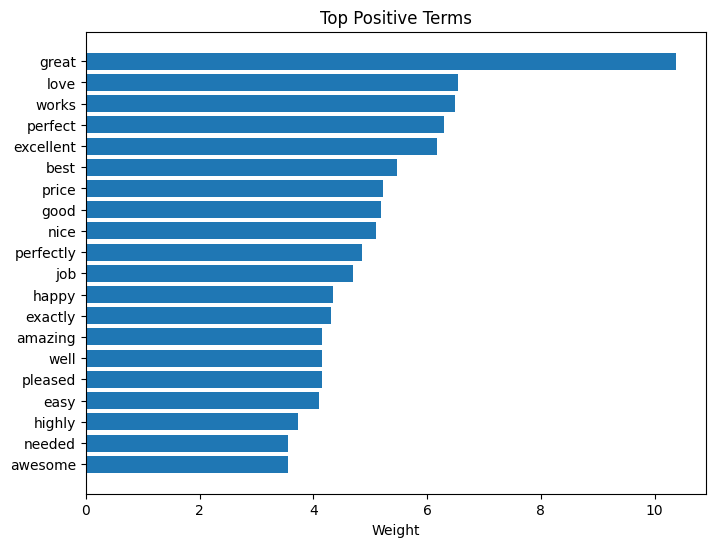

In [50]:
plt.figure(figsize=(8, 6))
plt.barh(top_positive["word"], top_positive["weight"])
plt.gca().invert_yaxis()
plt.title("Top Positive Terms")
plt.xlabel("Weight")
plt.savefig("../results/figures/top_positive_terms.png", dpi=300, bbox_inches="tight")
plt.show()

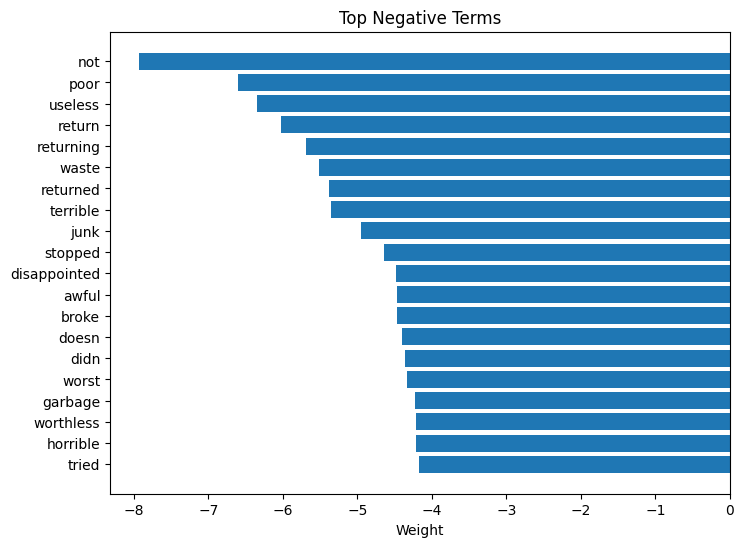

In [51]:
plt.figure(figsize=(8, 6))
plt.barh(top_negative["word"], top_negative["weight"])
plt.gca().invert_yaxis()
plt.title("Top Negative Terms")
plt.xlabel("Weight")
plt.savefig("../results/figures/top_negative_terms.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Calibration
We check whether predicted probabilities are well calibrated.

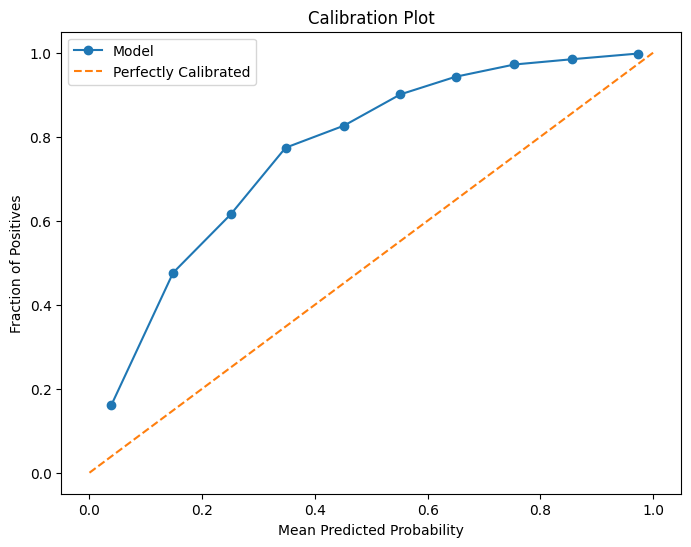

In [52]:
prob_true, prob_pred = calibration_curve(y_test_binary, y_prob_lr_balanced, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly Calibrated")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Plot")
plt.legend()
plt.savefig("../results/figures/calibration_plot.png", dpi=300, bbox_inches="tight")
plt.show()

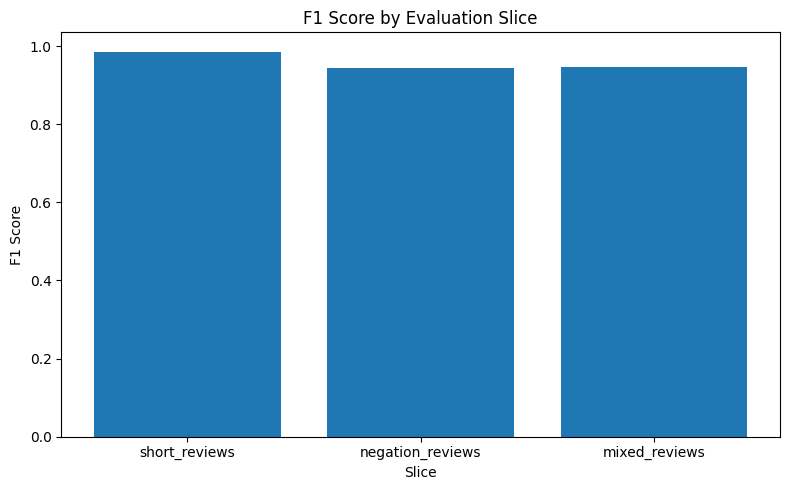

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(slice_results["slice"], slice_results["f1"])
plt.title("F1 Score by Evaluation Slice")
plt.ylabel("F1 Score")
plt.xlabel("Slice")
plt.tight_layout()
plt.savefig("../results/figures/slice_f1_bar_chart.png", dpi=300)
plt.show()

## 14. Slice-Based Evaluation
Aggregate performance can hide systematic weaknesses.

To probe reliability more carefully, we evaluate the best model on several linguistically meaningful subsets:
- short reviews
- reviews containing negation
- reviews containing mixed-sentiment cues

In [53]:
y_pred_final = y_pred_lr_balanced_tuned

slice_df = pd.DataFrame({
    "text": x_test.reset_index(drop=True),
    "y_true": y_test.reset_index(drop=True),
    "y_pred": pd.Series(y_pred_final)
})

slice_df["word_count"] = slice_df["text"].astype(str).str.split().str.len()
slice_df["short_review"] = slice_df["word_count"] < 20

slice_df["has_negation"] = slice_df["text"].str.contains(
    r"\b(?:not|no|never|don't|doesn't|isn't|wasn't|can't|won't)\b",
    case=False,
    regex=True
)

slice_df["has_mixed"] = slice_df["text"].str.contains(
    r"\b(?:but|however|although|though)\b",
    case=False,
    regex=True
)

In [54]:
def eval_slice(name, mask):
    subset = slice_df[mask]

    if len(subset) == 0:
        return {"slice": name, "n": 0, "f1": None}

    return {
        "slice": name,
        "n": len(subset),
        "f1": f1_score(
            subset["y_true"],
            subset["y_pred"],
            pos_label="positive",
            zero_division=0
        )
    }

slice_results = pd.DataFrame([
    eval_slice("short_reviews", slice_df["short_review"]),
    eval_slice("negation_reviews", slice_df["has_negation"]),
    eval_slice("mixed_reviews", slice_df["has_mixed"])
])

slice_results

,slice,n,f1
0,short_reviews,6527,0.986633
1,negation_reviews,7868,0.945652
2,mixed_reviews,5499,0.947895


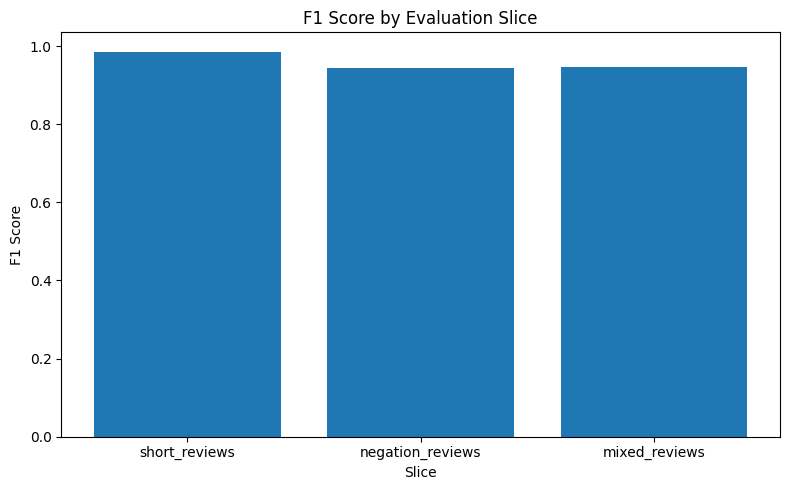

In [55]:
plt.figure(figsize=(8, 5))
plt.bar(slice_results["slice"], slice_results["f1"])
plt.title("F1 Score by Evaluation Slice")
plt.ylabel("F1 Score")
plt.xlabel("Slice")
plt.tight_layout()
plt.savefig("../results/figures/slice_f1_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Error Analysis
We inspect misclassified examples from the best model to understand recurring failure modes.

In [56]:
error_analysis_df = pd.DataFrame({
    "reviewText": x_test.reset_index(drop=True),
    "true_label": y_test_binary.reset_index(drop=True),
    "predicted_label": np.where(pd.Series(y_pred_final) == "positive", 1, 0),
    "pred_prob": y_prob_lr_balanced
})

misclassified = error_analysis_df[
    error_analysis_df["true_label"] != error_analysis_df["predicted_label"]
].copy()

print("Total misclassified reviews:", len(misclassified))
misclassified.head()

Total misclassified reviews: 1001


,reviewText,true_label,predicted_label,pred_prob
10,This was the third Logitech trackball I've own...,0,1,0.364069
50,"It just makes everything darker, does not see...",0,1,0.403894
58,"I could not figure out why my HD would go out,...",1,0,0.041417
112,"I've heard lots of good things about Tiffen, b...",0,1,0.239111
118,the wipes are relly dry . i wish they were moi...,0,1,0.659026


In [57]:
false_positives = misclassified[
    (misclassified["true_label"] == 0) & (misclassified["predicted_label"] == 1)
].sort_values(by="pred_prob", ascending=False).copy()

false_negatives = misclassified[
    (misclassified["true_label"] == 1) & (misclassified["predicted_label"] == 0)
].sort_values(by="pred_prob", ascending=True).copy()

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 708
False Negatives: 293


In [58]:
print("TOP FALSE POSITIVES:")
display(false_positives.head(20))
print("\nTOP FALSE NEGATIVES:")
display(false_negatives.head(20))

TOP FALSE POSITIVES:


,reviewText,true_label,predicted_label,pred_prob
8697,works great,0,1,0.999999
3703,good,0,1,0.995388
5067,good,0,1,0.995388
16801,"Its works on and off, the main cable has a swe...",0,1,0.990678
7535,as described,0,1,0.988381
7133,I've seen this and other adapters in action. ...,0,1,0.984802
16294,I am torn on this purchase. My radio is in a J...,0,1,0.969350
9589,It fits so awkwardly.,0,1,0.967693
8796,I wanted a macro lens that would also be good ...,0,1,0.967206
6585,used these on a safari on Africa. They are li...,0,1,0.959746



TOP FALSE NEGATIVES:


,reviewText,true_label,predicted_label,pred_prob
698,Didn't charge the phone .had to have a new pho...,1,0,0.001198
18407,Poor quality,1,0,0.001599
13534,Unit defective returned,1,0,0.001704
6991,"Amazon recommended this product. However, it w...",1,0,0.002041
8118,not bad but doesnt stay in place,1,0,0.002734
17176,"Wow, I ordered on a Sunday AM and the product ...",1,0,0.003225
13105,I broke the one that came with my large antenn...,1,0,0.003259
1651,"Purchased but returned, because I was able to ...",1,0,0.004842
10106,This was sent back because it was too small,1,0,0.006286
6611,This was sent back because it was too small,1,0,0.006286


## 16. Manual Annotation Preparation
We export a clean sample of high-confidence errors for manual labeling.

In [59]:
misclassified_display = misclassified.copy()
misclassified_display["reviewText"] = misclassified_display["reviewText"].str.replace("\n", " ", regex=False)

sample_for_annotation = misclassified_display.head(30).copy()
sample_for_annotation["error_type"] = ""
sample_for_annotation["notes"] = ""

sample_for_annotation.to_excel("../results/error_analysis/misclassified_clean_annotate.xlsx", index=False)
misclassified.to_csv("../results/error_analysis/misclassified_samples_clean.csv", index=False)

print("Saved files for manual annotation.")

Saved files for manual annotation.


## 17. Optional In-Notebook Manual Annotation
If you want to keep a manually labeled subset directly in the notebook, you can annotate a sample here.
This mirrors the pattern already used in your earlier notebook version.


In [60]:
sample_errors = pd.concat([false_positives.head(20), false_negatives.head(20)]).copy()
sample_errors["error_type"] = ""
sample_errors.head()

,reviewText,true_label,predicted_label,pred_prob,error_type
8697,works great,0,1,0.999999,
3703,good,0,1,0.995388,
5067,good,0,1,0.995388,
16801,"Its works on and off, the main cable has a swe...",0,1,0.990678,
7535,as described,0,1,0.988381,


You can fill `sample_errors["error_type"]` manually in the notebook or use the exported Excel file instead.
For the final project, the Excel workflow is cleaner because it avoids hard-coded row indices.

## 18. Error Category Analysis
After manual annotation, load the reviewed file and analyze which failure modes are most common.

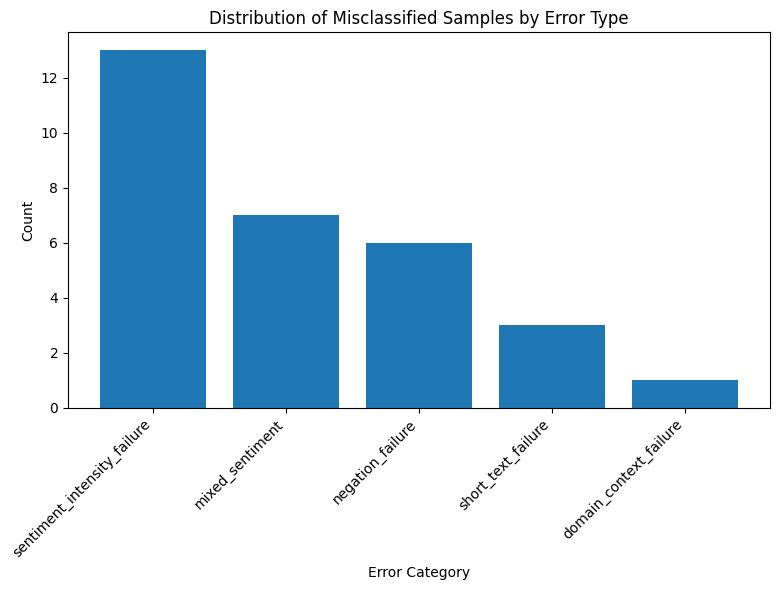

In [61]:
annotated_path = "../results/error_analysis/annotated_error_samples.xlsx"

if os.path.exists(annotated_path):
    misclassified_annotated = pd.read_excel(annotated_path)
    error_counts = misclassified_annotated["error_type"].value_counts()
    error_counts.to_csv("../results/error_analysis/error_categories.csv", header=["count"])

    plt.figure(figsize=(8, 6))
    plt.bar(error_counts.index, error_counts.values)
    plt.xlabel("Error Category")
    plt.ylabel("Count")
    plt.title("Distribution of Misclassified Samples by Error Type")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("../results/figures/error_category_bar_chart.png", dpi=300, bbox_inches="tight")
    plt.show()

    error_counts
else:
    print("annotated_error_samples.xlsx not found. Annotate the exported file first, then rerun this cell.")

## 19. Save Outputs
We save all summary tables for use in the README and results folder.

In [62]:
model_comparison.to_csv("../results/tables/model_comparison.csv", index=False)
threshold_df.to_csv("../results/tables/threshold_results.csv", index=False)
ablation_results.to_csv("../results/tables/ablation_results.csv", index=False)
slice_results.to_csv("../results/tables/slice_evaluation.csv", index=False)

print("Saved all result tables.")

Saved all result tables.


## 20. Key Findings

- The best-performing configuration is Logistic Regression with class weighting and threshold tuning.
- Threshold optimization substantially improves F1-score over the default threshold.
- Slice-based evaluation shows that the model performs especially well on short reviews.
- Performance drops on negation-heavy and mixed-sentiment reviews, indicating that strong aggregate metrics can still hide systematic linguistic failure modes.
- Error analysis helps identify recurring categories such as negation, mixed sentiment, contextual ambiguity, and weak sentiment signals.